<a href="https://colab.research.google.com/github/palash116/FirstCode2025/blob/HomeWork/Week9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Font family setup

In [43]:
import matplotlib
# Set font size and family for the entire figure
matplotlib.rcParams['font.size'] = 12

# Importing Dataset

In [4]:
import pandas as pd
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

Mounted at /content/drive


In [44]:
# Access the file in Google Drive
df = pd.read_csv("/content/drive/MyDrive/data/diabetes.csv")

# Basic Information

In [45]:
df

,age,gender,ethnicity,education_level,income_level,employment_status,smoking_status,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,...,cholesterol_total,hdl_cholesterol,ldl_cholesterol,triglycerides,glucose_fasting,glucose_postprandial,insulin_level,hba1c,diabetes_risk_score,diabetes
0,58,Male,Asian,Highschool,Lower-Middle,Employed,Never,0,215,5.7,...,239,41,160,145,136,236,6.36,8.18,29.6,1
1,48,Female,White,Highschool,Middle,Employed,Former,1,143,6.7,...,116,55,50,30,93,150,2.00,5.63,23.0,0
2,60,Male,Hispanic,Highschool,Middle,Unemployed,Never,1,57,6.4,...,213,66,99,36,118,195,5.07,7.51,44.7,1
3,74,Female,Black,Highschool,Low,Retired,Never,0,49,3.4,...,171,50,79,140,139,253,5.28,9.03,38.2,1
4,46,Male,White,Graduate,Middle,Retired,Never,1,109,7.2,...,210,52,125,160,137,184,12.74,7.20,23.5,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,46,Male,Other,Graduate,Upper-Middle,Unemployed,Former,1,136,8.3,...,227,45,150,116,113,109,14.58,5.55,26.0,0
99996,41,Female,White,Graduate,Middle,Employed,Never,3,76,8.8,...,207,55,123,146,96,146,9.02,5.97,24.4,0
99997,57,Female,Black,No formal,Upper-Middle,Employed,Former,4,121,9.9,...,189,50,111,184,93,132,2.57,5.21,27.6,0
99998,47,Female,Black,Highschool,Lower-Middle,Retired,Never,3,52,5.9,...,173,68,91,116,106,117,9.81,5.53,26.4,0


In [46]:
df.shape

(100000, 30)

# Handle Missing Values

In [47]:
# Check for missing values
missing_values = df.isnull().sum()
missing_values = missing_values[missing_values > 0]  # Only show columns with missing values

print("Columns with Missing Values:\n", missing_values)


# Identify numerical and categorical columns
numerical_cols = df.select_dtypes(include=['float64', 'int64']).columns
categorical_cols = df.select_dtypes(include=['object']).columns

# Fill missing values in numerical columns with median
df[numerical_cols] = df[numerical_cols].fillna(df[numerical_cols].median())

# Fill missing values in categorical columns with mode
df[categorical_cols] = df[categorical_cols].fillna(df[categorical_cols].mode().iloc[0])

# Verify if missing values are filled
print("Missing values after filling:\n", df.isnull().sum().sum())  # Should be 0 if all missing values are handled

Columns with Missing Values:
 Series([], dtype: int64)
Missing values after filling:
 0


In [48]:
# Print the names of the features (columns)
print(df.columns)

Index(['age', 'gender', 'ethnicity', 'education_level', 'income_level',
       'employment_status', 'smoking_status', 'alcohol_consumption_per_week',
       'physical_activity_minutes_per_week', 'diet_score',
       'sleep_hours_per_day', 'screen_time_hours_per_day',
       'family_history_diabetes', 'hypertension_history',
       'cardiovascular_history', 'bmi', 'waist_to_hip_ratio', 'systolic_bp',
       'diastolic_bp', 'heart_rate', 'cholesterol_total', 'hdl_cholesterol',
       'ldl_cholesterol', 'triglycerides', 'glucose_fasting',
       'glucose_postprandial', 'insulin_level', 'hba1c', 'diabetes_risk_score',
       'diabetes'],
      dtype='object')


# Data Preprocessing

## Features Selection using mutual information

In [49]:
import pandas as pd
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import LabelEncoder

# Define target and features
target = 'diabetes'
X = df.drop(columns=[target])
y = df[target]

#Identify categorical and numerical columns
cat_cols = X.select_dtypes(include=['object', 'category']).columns
num_cols = X.select_dtypes(include=['int64', 'float64']).columns

#Label encode categorical columns
le = LabelEncoder()
for col in cat_cols:
    X[col] = le.fit_transform(X[col].astype(str))

#Compute Mutual Information
mi_scores = mutual_info_classif(X, y, discrete_features=[col in cat_cols for col in X.columns], random_state=42)

# Create MI DataFrame
mi_df = pd.DataFrame({
    'Feature': X.columns,
    'Mutual_Information': mi_scores
}).sort_values(by='Mutual_Information', ascending=False).reset_index(drop=True)

# Show top important features ----
print("Top Important Features based on Mutual Information:")
print(mi_df)



Top Important Features based on Mutual Information:
                               Feature  Mutual_Information
0                                hba1c        4.405001e-01
1                 glucose_postprandial        2.859723e-01
2                      glucose_fasting        1.664246e-01
3                  diabetes_risk_score        4.102554e-02
4              family_history_diabetes        2.385330e-02
5                                  age        1.027302e-02
6                          systolic_bp        5.123892e-03
7                                  bmi        4.175469e-03
8   physical_activity_minutes_per_week        3.975001e-03
9                         diastolic_bp        3.348973e-03
10                     ldl_cholesterol        2.634377e-03
11                  waist_to_hip_ratio        2.288999e-03
12        alcohol_consumption_per_week        2.287165e-03
13              cardiovascular_history        1.514076e-03
14                 sleep_hours_per_day        1.320161e-03
15  

In [50]:
#Select top 10 features
top_n = 10  # choose how many top features you want
top_features = mi_df.head(top_n)['Feature']

# Create new dataset with target + top features
new_df = df[top_features.tolist() + [target]]

#  Show results
print("Top features selected based on Mutual Information:")
print(top_features.to_list())


Top features selected based on Mutual Information:
['hba1c', 'glucose_postprandial', 'glucose_fasting', 'diabetes_risk_score', 'family_history_diabetes', 'age', 'systolic_bp', 'bmi', 'physical_activity_minutes_per_week', 'diastolic_bp']


In [51]:
print("\nNew dataset shape:", new_df.shape)


New dataset shape: (100000, 11)


## Convert target column 1 → 'yes', 0 → 'no'

In [52]:
import pandas as pd
new_df['diabetes'] = new_df['diabetes'].astype(int)

/tmp/ipython-input-15902926.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['diabetes'] = new_df['diabetes'].astype(int)


In [53]:
# Convert 1 → 'yes', 0 → 'no'

new_df['diabetes'] = new_df['diabetes'].map({1: 'yes', 0: 'no'})

/tmp/ipython-input-2429955928.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['diabetes'] = new_df['diabetes'].map({1: 'yes', 0: 'no'})


In [54]:
display(new_df)

,hba1c,glucose_postprandial,glucose_fasting,diabetes_risk_score,family_history_diabetes,age,systolic_bp,bmi,physical_activity_minutes_per_week,diastolic_bp,diabetes
0,8.18,236,136,29.6,0,58,134,30.5,215,78,yes
1,5.63,150,93,23.0,0,48,129,23.1,143,76,no
2,7.51,195,118,44.7,1,60,115,22.2,57,73,yes
3,9.03,253,139,38.2,0,74,120,26.8,49,93,yes
4,7.20,184,137,23.5,0,46,92,21.2,109,67,yes
...,...,...,...,...,...,...,...,...,...,...,...
99995,5.55,109,113,26.0,0,46,126,29.8,136,74,no
99996,5.97,146,96,24.4,0,41,130,26.5,76,76,no
99997,5.21,132,93,27.6,0,57,107,25.6,121,87,no
99998,5.53,117,106,26.4,0,47,115,26.8,52,77,no


## After Processing

In [56]:
new_df['diabetes'].value_counts()

,count
diabetes,
yes,59998
no,40002


## StandardScaler

In [57]:
import numpy as np
from sklearn.preprocessing import StandardScaler, LabelEncoder

## Preprocessing steps
# Replace infinity and large values with NaNs
new_df = new_df.replace([np.inf, -np.inf], np.nan)
new_df = new_df.replace(to_replace=[r'^(-?\d+\.\d+e\+\d+|-?\d+\.\d+e-\d+|-?\d+\.\d+|-?\d+)$', r'^(-?\d+)$'], value=np.nan, regex=True)

# Drop rows containing NaNs
new_df.dropna(inplace=True)

# Separate numerical and categorical columns, excluding the '	diagnosed_diabetes' column from categorical columns
num_cols = new_df.select_dtypes(include=['float64', 'int64']).columns
cat_cols = new_df.select_dtypes(include=['object']).columns
cat_cols = cat_cols.difference(['diabetes'])

# Normalize numerical columns
scaler = StandardScaler()
new_df[num_cols] = scaler.fit_transform(new_df[num_cols])

# Ensure all categorical values are strings
new_df[cat_cols] = new_df[cat_cols].astype(str)

# Encode categorical columns
encoder = LabelEncoder()
new_df[cat_cols] = new_df[cat_cols].apply(encoder.fit_transform)

# Display the processed DataFrame
new_df

,hba1c,glucose_postprandial,glucose_fasting,diabetes_risk_score,family_history_diabetes,age,systolic_bp,bmi,physical_activity_minutes_per_week,diastolic_bp,diabetes
0,2.038566,2.455606,1.830223,-0.068682,-0.530172,0.504956,1.274180,1.362636,1.138363,0.337328,yes
1,-1.094431,-0.324388,-1.332578,-0.797042,-0.530172,-0.135884,0.924138,-0.700550,0.285376,0.093551,no
2,1.215387,1.130260,0.506260,1.597716,1.886181,0.633124,-0.055979,-0.951478,-0.733470,-0.272115,yes
3,3.082899,3.005140,2.050884,0.880392,-0.530172,1.530299,0.294063,0.331043,-0.828246,2.165658,yes
4,0.834512,0.774679,1.903777,-0.741863,-0.530172,-0.264052,-1.666172,-1.230287,-0.117424,-1.003447,yes
...,...,...,...,...,...,...,...,...,...,...,...
99995,-1.192721,-1.649734,0.138492,-0.465969,-0.530172,-0.264052,0.714113,1.167469,0.202447,-0.150227,no
99996,-0.676698,-0.453690,-1.111917,-0.642541,-0.530172,-0.584472,0.994147,0.247400,-0.508376,0.093551,no
99997,-1.610454,-0.906247,-1.332578,-0.289397,-0.530172,0.440872,-0.616047,-0.003528,0.024741,1.434326,no
99998,-1.217294,-1.391130,-0.376382,-0.421826,-0.530172,-0.199968,-0.055979,0.331043,-0.792705,0.215439,no


# Traing and Test Division

In [59]:
# Define label and feature columns
X = new_df.drop(columns=['diabetes'])
y = new_df['diabetes']

In [60]:
from sklearn.model_selection import train_test_split

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,                   # Features and target
    test_size=0.2,          # 20% test, 80% train
    random_state=42,        # For reproducibility
)

# Confirm sizes
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape:  {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape:  {y_test.shape}")

X_train shape: (80000, 10)
X_test shape:  (20000, 10)
y_train shape: (80000,)
y_test shape:  (20000,)


# Train & Evaluate Decision Tree Classifier

Accuracy:  0.8603
Precision: 0.8599
Recall:    0.8603
F1 Score:  0.8600


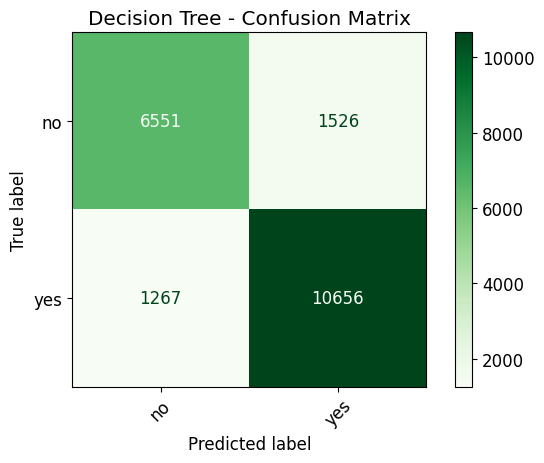

Classification Report:
              precision    recall  f1-score   support

          no    0.83794   0.81107   0.82428      8077
         yes    0.87473   0.89373   0.88413     11923

    accuracy                        0.86035     20000
   macro avg    0.85634   0.85240   0.85421     20000
weighted avg    0.85987   0.86035   0.85996     20000



In [61]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score,
    roc_curve, ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

# 1. Train Decision Tree Classifier
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

# 2. Predict on Test Set
y_pred = dt_model.predict(X_test)

# 3. Evaluation Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

# 4. Print Basic Metrics
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")

# 5. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=dt_model.classes_).plot(cmap='Greens', xticks_rotation=45)
plt.title("Decision Tree - Confusion Matrix")
plt.tight_layout()
plt.show()

# 6. Classification Report
print("Classification Report:")
print(classification_report(y_test, y_pred, zero_division=0, digits=5))

# Train & Evaluate Random Forest Classifier

Accuracy:  0.91680
Precision: 0.92802
Recall:    0.91680
F1 Score:  0.91753


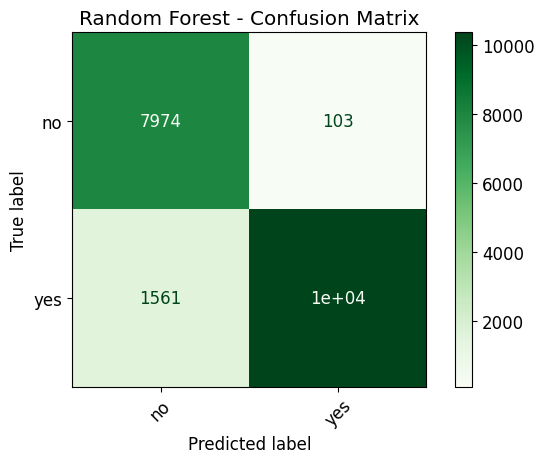

Classification Report:
              precision    recall  f1-score   support

          no    0.83629   0.98725   0.90552      8077
         yes    0.99016   0.86908   0.92567     11923

    accuracy                        0.91680     20000
   macro avg    0.91322   0.92816   0.91560     20000
weighted avg    0.92802   0.91680   0.91753     20000



In [62]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score,
    roc_curve, ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

# 1. Train Random Forest Classifier
rf_model= RandomForestClassifier(n_estimators=10, random_state=42)
rf_model.fit(X_train, y_train)

# 2. Predict on Test Set
y_pred = rf_model.predict(X_test)

# 3. Evaluation Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

# 4. Print Basic Metrics (5-digit precision)
print(f"Accuracy:  {accuracy:.5f}")
print(f"Precision: {precision:.5f}")
print(f"Recall:    {recall:.5f}")
print(f"F1 Score:  {f1:.5f}")

# 5. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=rf_model.classes_).plot(cmap='Greens', xticks_rotation=45)
plt.title("Random Forest - Confusion Matrix")
plt.tight_layout()
plt.show()

# 6. Classification Report (5-digit precision)
print("Classification Report:")
print(classification_report(y_test, y_pred, zero_division=0, digits=5))

## Modified Cofusion Matrix for Random forest

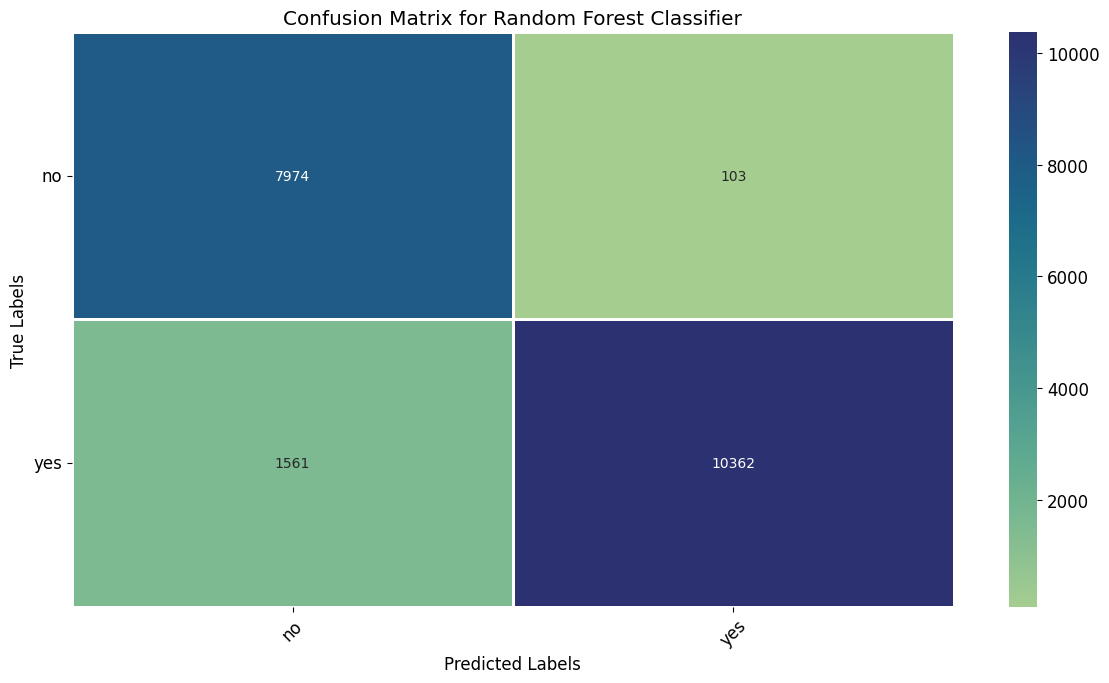

In [63]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

cm = confusion_matrix(y_test, y_pred)

# Colormap
cmap = sns.color_palette("crest", as_cmap=True)

# Automatically get class labels from model
class_labels = rf_model.classes_

# Create figure and axis
fig, ax = plt.subplots(figsize=(12, 7))

# Plot CM
sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, cbar=True,
            ax=ax, annot_kws={"fontsize": 10}, linewidths=1, linecolor='white')

ax.set_title("Confusion Matrix for Random Forest Classifier")
ax.set_xlabel("Predicted Labels")
ax.set_ylabel("True Labels")
ax.set_xticklabels(class_labels, rotation=45)
ax.set_yticklabels(class_labels, rotation=0)

plt.tight_layout()
plt.show()

## ROC curve

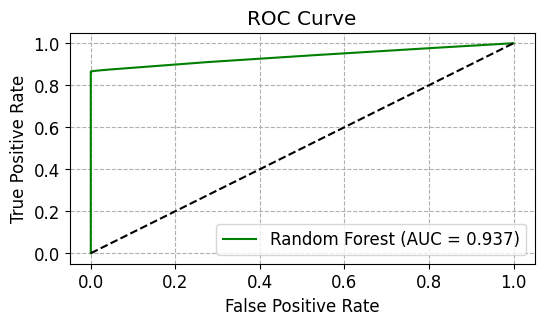

In [76]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Get prediction probabilities for class 'M'
y_prob = rf_model.predict_proba(X_test)[:, 1]
y_true = (y_test == 'yes').astype(int)

# Compute ROC curve values
fpr, tpr, _ = roc_curve(y_true, y_prob)
auc = roc_auc_score(y_true, y_prob)

# Plot ROC Curve
plt.figure(figsize=(6, 3))
plt.plot(fpr, tpr, color='green', label=f'Random Forest (AUC = {auc:.3f})')
plt.plot([0, 1], [0, 1], 'k--')  # diagonal line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.grid(True, linestyle='--')  # dashed grid lines
plt.show()

## Cost Function Convergence Over Iterati

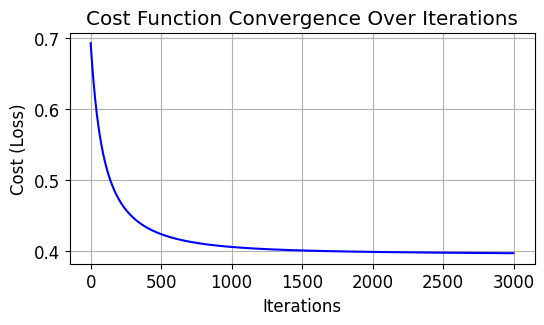

In [77]:
import numpy as np
import matplotlib.pyplot as plt

# Convert y_train to binary (0 for no, 1 for yes)
y_train_bin = (y_train == 'yes').astype(int).values

# Initialize parameters
theta = np.zeros(X_train.shape[1])
alpha = 0.01
iterations = 3000
costs = []

# Sigmoid function
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# Gradient Descent using direct X_train
for i in range(iterations):
    z = np.dot(X_train, theta)
    h = sigmoid(z)
    error = h - y_train_bin
    cost = (-1 / len(y_train_bin)) * np.sum(
        y_train_bin * np.log(h + 1e-9) + (1 - y_train_bin) * np.log(1 - h + 1e-9)
    )
    costs.append(cost)
    gradient = np.dot(X_train.T, error) / len(y_train_bin)
    theta -= alpha * gradient

# Plot cost vs. iteration
plt.figure(figsize=(6,3))
plt.plot(range(iterations), costs, color='blue')
plt.title('Cost Function Convergence Over Iterations')
plt.xlabel('Iterations')
plt.ylabel('Cost (Loss)')
plt.grid(True)
plt.show()

# Train & Evaluate KNN Classifier

Accuracy:  0.86245
Precision: 0.86659
Recall:    0.86245
F1 Score:  0.86327


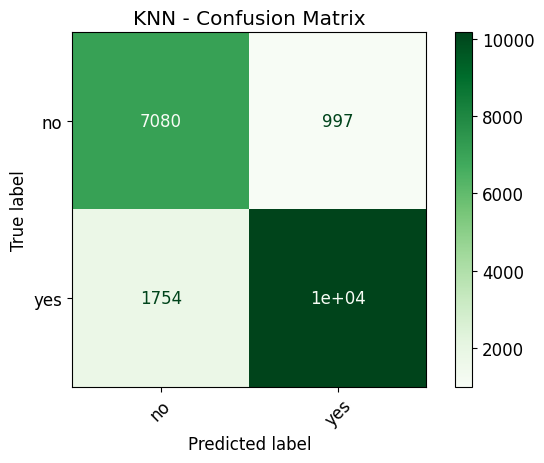

Classification Report:
              precision    recall  f1-score   support

          no    0.80145   0.87656   0.83732      8077
         yes    0.91071   0.85289   0.88085     11923

    accuracy                        0.86245     20000
   macro avg    0.85608   0.86473   0.85909     20000
weighted avg    0.86659   0.86245   0.86327     20000



In [64]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score,
    roc_curve, ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

# 1. Train KNN Classifier
knn_model = KNeighborsClassifier(n_neighbors=5)  # You can tune n_neighbors
knn_model.fit(X_train, y_train)

# 2. Predict on Test Set
y_pred = knn_model.predict(X_test)

# 3. Evaluation Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

# 4. Print Basic Metrics (5-digit precision)
print(f"Accuracy:  {accuracy:.5f}")
print(f"Precision: {precision:.5f}")
print(f"Recall:    {recall:.5f}")
print(f"F1 Score:  {f1:.5f}")

# 5. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=knn_model.classes_).plot(cmap='Greens', xticks_rotation=45)
plt.title("KNN - Confusion Matrix")
plt.tight_layout()
plt.show()

# 6. Classification Report (5-digit precision)
print("Classification Report:")
print(classification_report(y_test, y_pred, zero_division=0, digits=5))

## Modified Confusion Matrix for KNN

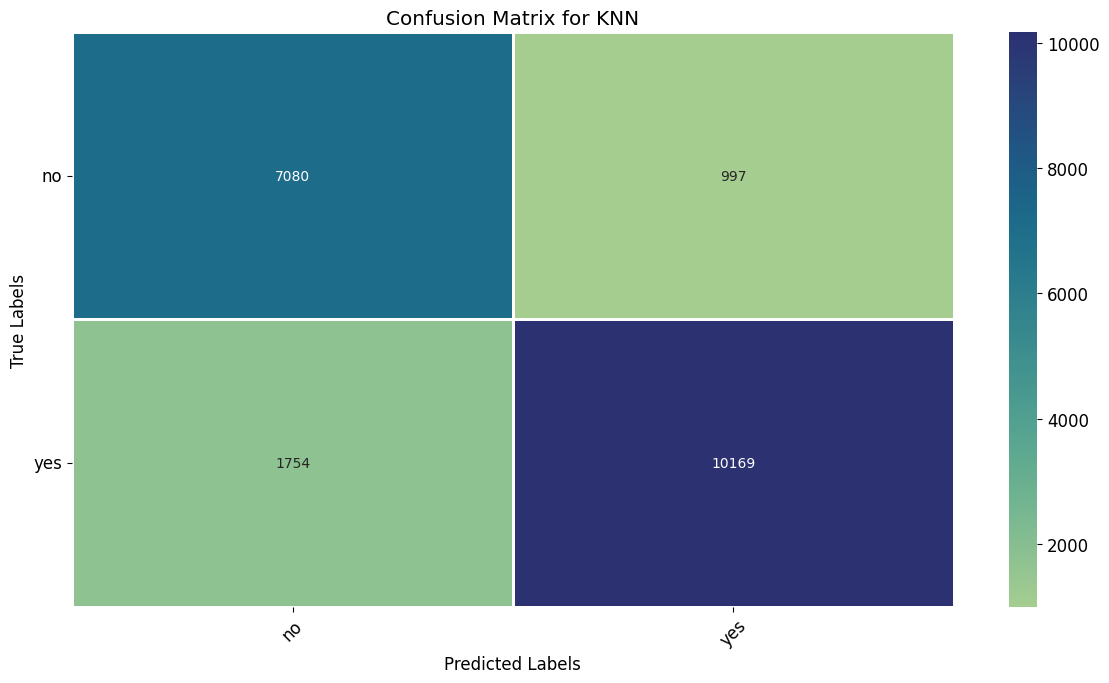

In [65]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

cm = confusion_matrix(y_test, y_pred)

# Colormap
cmap = sns.color_palette("crest", as_cmap=True)

# Automatically get class labels from model
class_labels = knn_model.classes_

# Create figure and axis
fig, ax = plt.subplots(figsize=(12, 7))

# Plot CM
sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, cbar=True,
            ax=ax, annot_kws={"fontsize": 10}, linewidths=1, linecolor='white')

ax.set_title("Confusion Matrix for KNN")
ax.set_xlabel("Predicted Labels")
ax.set_ylabel("True Labels")
ax.set_xticklabels(class_labels, rotation=45)
ax.set_yticklabels(class_labels, rotation=0)

plt.tight_layout()
plt.show()

# Train & Evaluate Logistic Regression Model

In [66]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

# Train logistic regression
model = LogisticRegression(max_iter=500)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Classification Report:")
print(classification_report(y_test, y_pred, zero_division=0, digits=5))

Classification Report:
              precision    recall  f1-score   support

          no    0.83461   0.80723   0.82069      8077
         yes    0.87225   0.89164   0.88184     11923

    accuracy                        0.85755     20000
   macro avg    0.85343   0.84943   0.85127     20000
weighted avg    0.85705   0.85755   0.85714     20000



## Different Evaluation Metrics for logistic regression model

In [67]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

# Predictions
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]  # probability for ROC AUC

# Metrics
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, pos_label='yes')
rec = recall_score(y_test, y_pred, pos_label='yes')
f1 = f1_score(y_test, y_pred, pos_label='yes')
roc_auc = roc_auc_score((y_test == 'yes').astype(int), y_prob)

print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1-score : {f1:.4f}")
print(f"ROC AUC  : {roc_auc:.4f}")

Accuracy : 0.8576
Precision: 0.8723
Recall   : 0.8916
F1-score : 0.8818
ROC AUC  : 0.9330


## Confusion Matrix

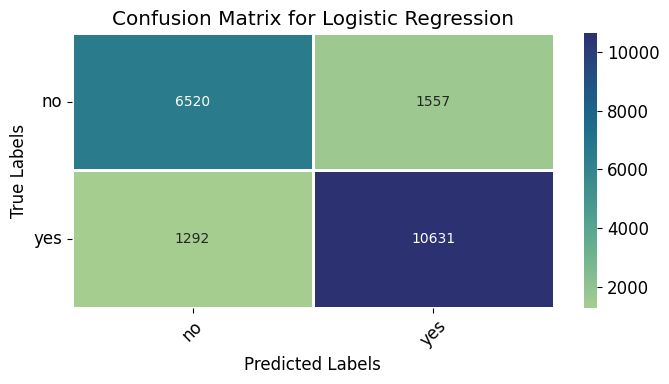

In [68]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

cm = confusion_matrix(y_test, y_pred)

# Colormap
cmap = sns.color_palette("crest", as_cmap=True)

# Automatically get class labels from model
class_labels = model.classes_

# Create figure and axis
fig, ax = plt.subplots(figsize=(7, 4))

# Plot CM
sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, cbar=True,
            ax=ax, annot_kws={"fontsize": 10}, linewidths=1, linecolor='white')

ax.set_title("Confusion Matrix for Logistic Regression")
ax.set_xlabel("Predicted Labels")
ax.set_ylabel("True Labels")
ax.set_xticklabels(class_labels, rotation=45)
ax.set_yticklabels(class_labels, rotation=0)

plt.tight_layout()
plt.show()


## ROC Curve

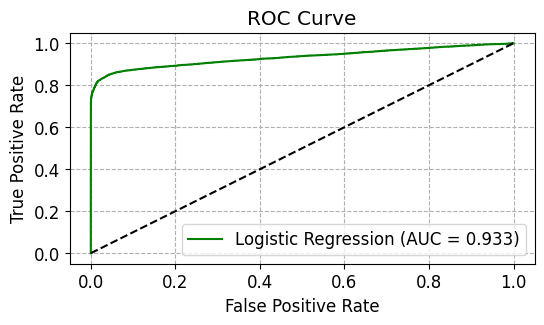

In [69]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Get prediction probabilities for class 'M'
y_prob = model.predict_proba(X_test)[:, 1]
y_true = (y_test == 'yes').astype(int)

# Compute ROC curve values
fpr, tpr, _ = roc_curve(y_true, y_prob)
auc = roc_auc_score(y_true, y_prob)

# Plot ROC Curve
plt.figure(figsize=(6, 3))
plt.plot(fpr, tpr, color='green', label=f'Logistic Regression (AUC = {auc:.3f})')
plt.plot([0, 1], [0, 1], 'k--')  # diagonal line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.grid(True, linestyle='--')  # dashed grid lines
plt.show()

## Cost Function Convergence Over Iterations

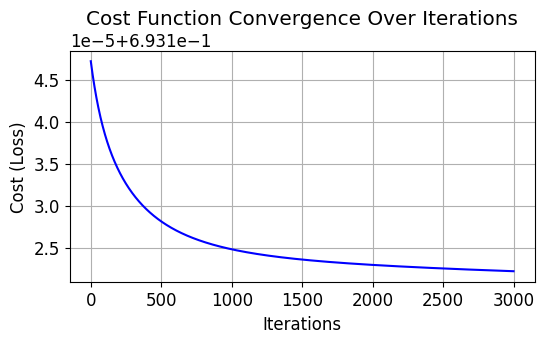

In [70]:
import numpy as np
import matplotlib.pyplot as plt

# Convert y_train to binary (0 for B, 1 for M)
y_train_bin = (y_train == 'M').astype(int).values

# Initialize parameters
theta = np.zeros(X_train.shape[1])
alpha = 0.01
iterations = 3000
costs = []

# Sigmoid function
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# Gradient Descent using direct X_train
for i in range(iterations):
    z = np.dot(X_train, theta)
    h = sigmoid(z)
    error = h - y_train_bin
    cost = (-1 / len(y_train_bin)) * np.sum(
        y_train_bin * np.log(h + 1e-9) + (1 - y_train_bin) * np.log(1 - h + 1e-9)
    )
    costs.append(cost)
    gradient = np.dot(X_train.T, error) / len(y_train_bin)
    theta -= alpha * gradient

# Plot cost vs. iteration
plt.figure(figsize=(6,3))
plt.plot(range(iterations), costs, color='blue')
plt.title('Cost Function Convergence Over Iterations')
plt.xlabel('Iterations')
plt.ylabel('Cost (Loss)')
plt.grid(True)
plt.show()

# Explainable AI (XAI)

## LIME (Local Interpretable Model-Agnostic Explanations)

In [71]:
!pip install lime

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 4.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=14f7deddd7c0acd57f47236056f5ef0dc91ae8ebb4b8e2656509da0db499aa18
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime


In [72]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

In [73]:
from lime import lime_tabular

# Initialize explainer
explainer = lime_tabular.LimeTabularExplainer(
    training_data=np.array(X_train),
    feature_names=X_train.columns,
    class_names=['no', 'yes'],  # or use list(model.classes_) if applicable
    mode='classification'
)

# Explain one sample (you can change index)
sample_index = 10
exp = explainer.explain_instance(
    data_row=X_test.iloc[sample_index],
    predict_fn=model.predict_proba
)

# Show explanation
exp.show_in_notebook(show_table=True)

## SHAP (SHapley Additive exPlanations)

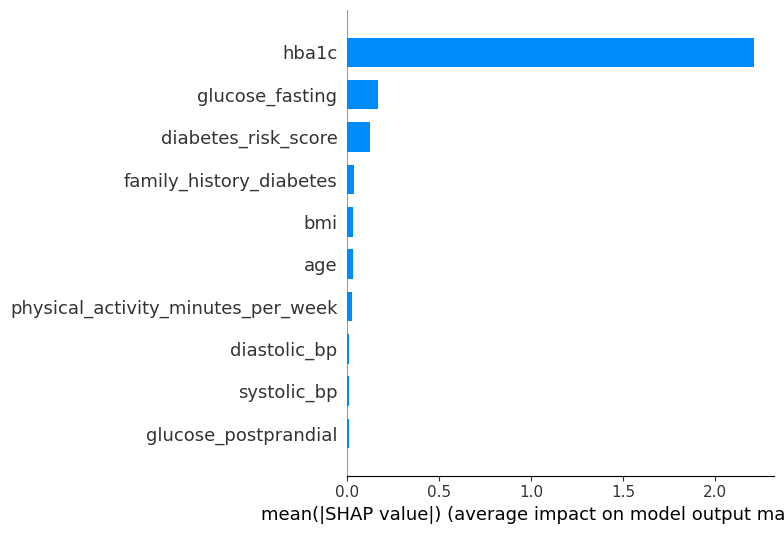

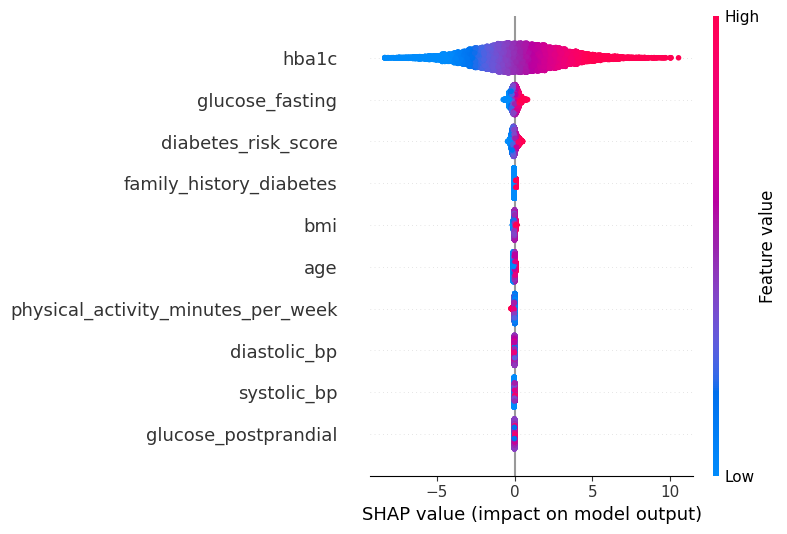

In [74]:
import shap

# Initialize SHAP explainer
explainer = shap.Explainer(model, X_train)
shap_values = explainer(X_test)

# Summary plot (global feature importance)
shap.summary_plot(shap_values, X_test, plot_type="bar")

# Detailed summary (beeswarm)
shap.summary_plot(shap_values, X_test)

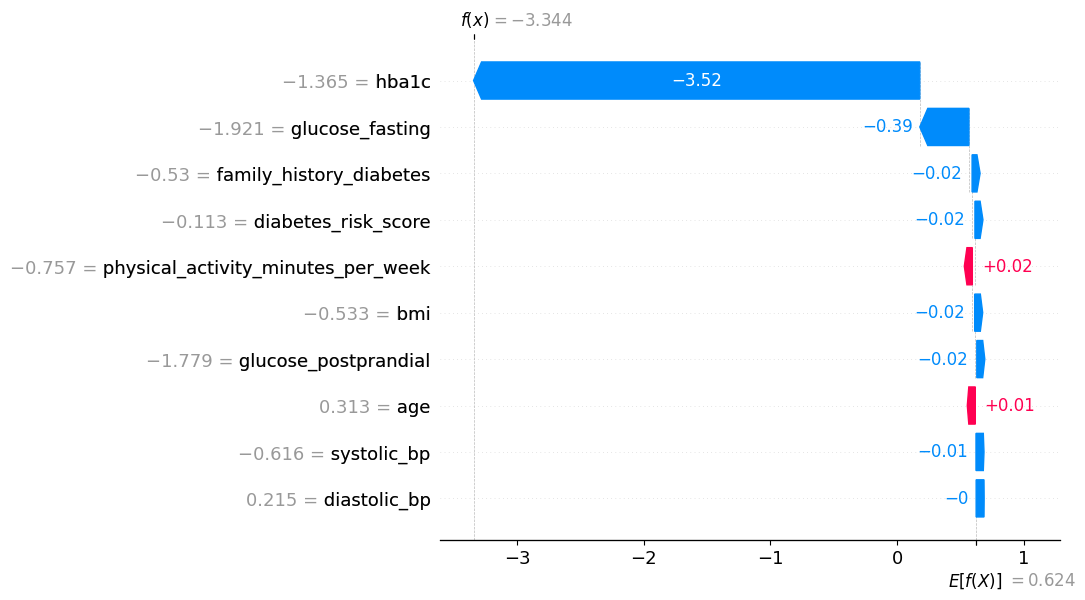

In [78]:
# Explain a single instance
shap.plots.waterfall(shap_values[0])
